In [23]:
#-- Import crucial libraries. --#
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [24]:
input_folder = '../Processed/'
output_dir = '../Figures/'

In [25]:
symbols_df = pd.read_csv('../Processed/Symbols.csv', encoding='utf-8-sig')
symbols_df['Symbols'] = symbols_df['Symbols'].str.strip().str.upper()
symbol_map = dict(zip(symbols_df['Symbols'], symbols_df['Meaning']))

In [26]:
file_pattern = os.path.join(input_folder, 'SCATSType*.csv')
all_files = glob.glob(file_pattern)

In [27]:
if not all_files:
    print(f"ERROR: No files found in '{input_folder}'.")
else:
    all_data = []
    for filename in all_files:
        df = pd.read_csv(filename, encoding='utf-8-sig', low_memory=False)
        df.columns = df.columns.str.strip().str.lower()
        
        required = ['site number', 'location description', 'site type', 'map reference']
        valid_cols = [c for c in required if c in df.columns]
        
        if 'site type' in valid_cols:
            all_data.append(df[valid_cols].copy())

    master_df = pd.concat(all_data, ignore_index=True)

    master_df = master_df.replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'NaN'], np.nan)
    
    master_df['site_type_upper'] = master_df['site type'].str.strip().str.upper()
    master_df['meaning'] = master_df['site_type_upper'].map(symbol_map).fillna(master_df['site_type_upper'])
    master_df = master_df.drop(columns=['site_type_upper'])

    for col in master_df.columns:
        if master_df[col].dtype == 'object':
            master_df[col] = master_df[col].str.lower()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4076\408392193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=master_df, y='meaning', order=order, palette='viridis')


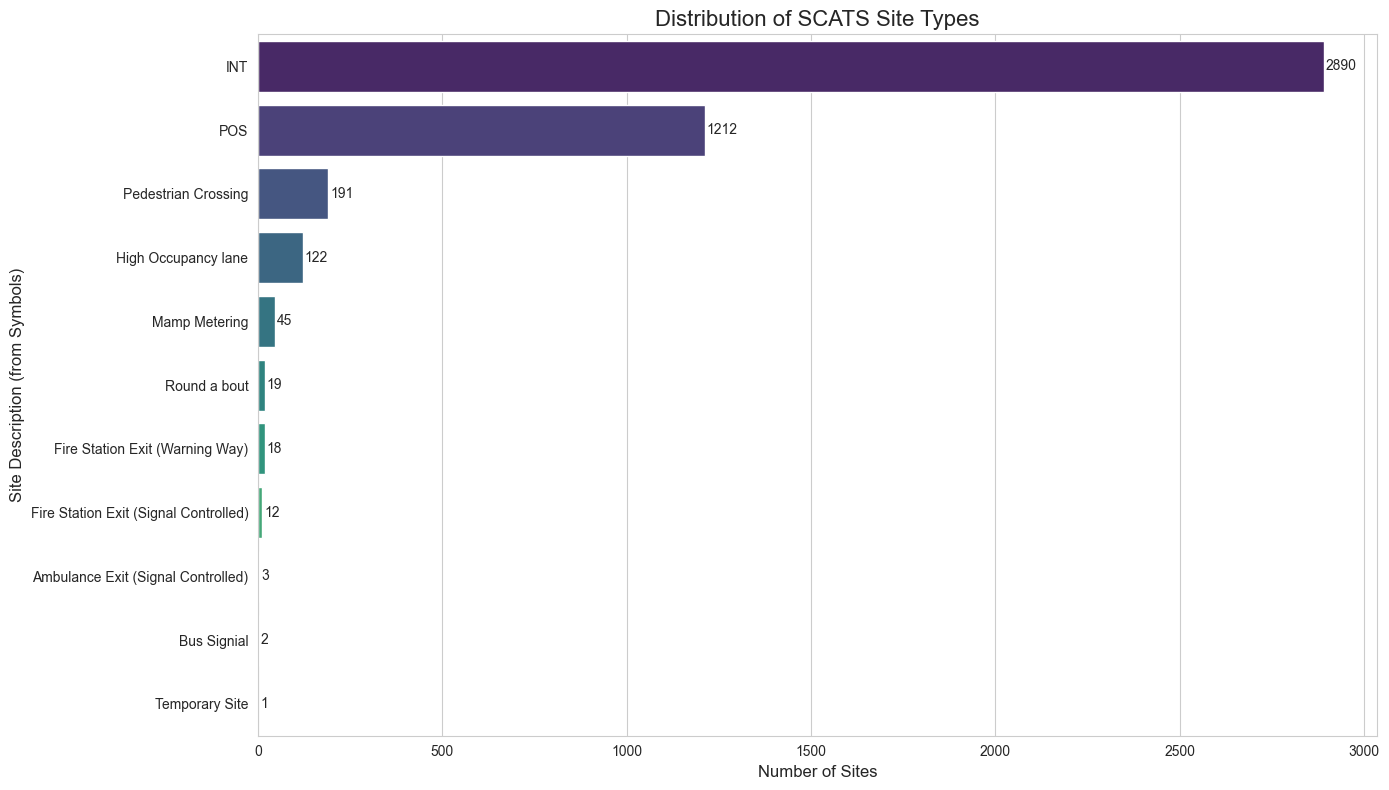

In [28]:
# --- CHART 1: SITE DISTRIBUTION (Purple/Green) ---
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
order = master_df['meaning'].value_counts().index
ax1 = sns.countplot(data=master_df, y='meaning', order=order, palette='viridis')
    
plt.title('Distribution of SCATS Site Types', fontsize=16)
plt.xlabel('Number of Sites', fontsize=12)
plt.ylabel('Site Description (from Symbols)', fontsize=12)
    
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_width())}', (p.get_width() + 5, p.get_y() + p.get_height()/2), va='center')
    
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '01_site_distribution.png'), dpi=300)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_4076\3013398623.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=plot_data, x='missing_percentage', y='meaning', palette='Reds_r')


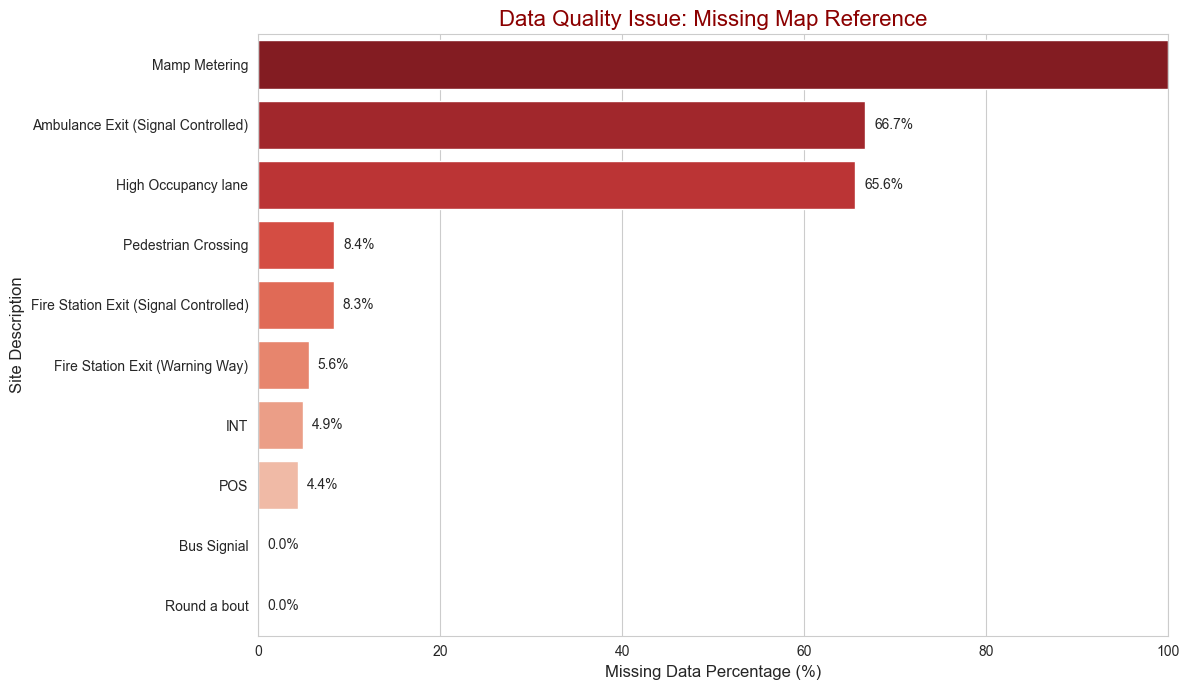

--- PROCESS COMPLETED ---
Total records processed: 4515
Charts saved in the '../Figures/' folder.


In [30]:
# --- CHART 2: MISSING DATA ANALYSIS (The "Problem" Showcase) ---
target_col = 'map reference' 
    
if target_col in master_df.columns:
    missing_stats = master_df.groupby('meaning')[target_col].apply(lambda x: x.isnull().mean() * 100).reset_index()
    missing_stats.columns = ['meaning', 'missing_percentage']
        
    plot_data = missing_stats.sort_values('missing_percentage', ascending=False).head(10)

    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    ax2 = sns.barplot(data=plot_data, x='missing_percentage', y='meaning', palette='Reds_r')
        
    plt.title(f'Data Quality Issue: Missing {target_col.title()}', fontsize=16, color='darkred')
    plt.xlabel('Missing Data Percentage (%)', fontsize=12)
    plt.ylabel('Site Description', fontsize=12)
    plt.xlim(0, 100)
        
    for p in ax2.patches:
        width = p.get_width()
        ax2.annotate(f'{width:.1f}%', (width + 1, p.get_y() + p.get_height()/2), va='center', fontsize=10)
        
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, '02_missing_data_analysis.png'), dpi=300)
    plt.show()

print(f"--- PROCESS COMPLETED ---")
print(f"Total records processed: {len(master_df)}")
print(f"Charts saved in the '{output_dir}' folder.")